In [2]:
# Import libraries
import os
import requests
import pandas as pd
from PIL import Image
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import cosine_similarity
import torchvision.models as models
import torchvision.transforms as transforms
import torch
import json
from io import BytesIO
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, normalize
from sklearn.cluster import DBSCAN
import json
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from IPython.display import display
import matplotlib.pyplot as plt

In [3]:
# Read data
df = pd.read_json('women_dress.json', lines=False)

print(df.head())

                                                data  \
0  {'EAN': [], 'size': 'XL', 'brand': 'SYNOLOCY',...   
1  {'EAN': ['5903887664936'], 'size': 'L', 'brand...   
2  {'EAN': [], 'size': 'S', 'brand': 'MAKOVER', '...   
3  {'EAN': ['5903938279232'], 'size': 'XS', 'bran...   
4  {'EAN': [], 'size': 'M', 'brand': 'STYLOVE', '...   

                      mirakl_product_id             creation_date  \
0  0d0d6215-eecd-458d-83d8-ca1586959ef2  2025-06-17T08:47:51.303Z   
1  5d31ab0b-5a08-4edd-a4ea-abbbd834d20b  2024-08-14T10:52:33.581Z   
2  a4d14441-3b91-434a-a3ad-6565d71a7894  2024-08-26T08:33:58.502Z   
3  0a438ef1-10d3-4a3c-8cf1-6c278959ab04  2024-08-27T05:48:47.629Z   
4  89089b4d-3eb7-4abd-8601-5997d98ccd1e  2024-08-26T08:32:52.570Z   

                update_date                           product_sku  \
0  2025-07-08T10:48:39.641Z  0d0d6215-eecd-458d-83d8-ca1586959ef2   
1  2024-08-14T11:34:15.392Z  5d31ab0b-5a08-4edd-a4ea-abbbd834d20b   
2  2024-08-26T09:10:45.275Z  a4d14441-3b9

In [4]:
import pandas as pd
import json

# === Step 1: Load dresses file ===
df_dresses = pd.read_json("women_dress.json", lines=False)

# === Step 2: Flatten fields like you did for sneakers ===
df_dresses["brand"] = df_dresses["data"].apply(lambda x: x.get("brand") if isinstance(x, dict) else "")
df_dresses["color"] = df_dresses["data"].apply(lambda x: x.get("color") if isinstance(x, dict) else "")
df_dresses["category"] = df_dresses["data"].apply(lambda x: x.get("category") if isinstance(x, dict) else "")
df_dresses["size"] = df_dresses["data"].apply(lambda x: x.get("size") if isinstance(x, dict) else "")
df_dresses["name [en_GB]"] = df_dresses["data"].apply(lambda x: x.get("name [en_GB]") if isinstance(x, dict) else "")
df_dresses["shortDescription [en_GB]"] = df_dresses["data"].apply(lambda x: x.get("shortDescription [en_GB]") if isinstance(x, dict) else "")
df_dresses["image"] = df_dresses["data"].apply(lambda x: x.get("mainImage", {}).get("original_url") if isinstance(x, dict) else "")

# Optional: check the first few rows
df_dresses.head()


,data,mirakl_product_id,creation_date,update_date,product_sku,acceptance,validation,synchronization,catalogs,product_urls,sources,selling_authorization,data_origin,brand,color,category,size,name [en_GB],shortDescription [en_GB],image
0,"{'EAN': [], 'size': 'XL', 'brand': 'SYNOLOCY',...",0d0d6215-eecd-458d-83d8-ca1586959ef2,2025-06-17T08:47:51.303Z,2025-07-08T10:48:39.641Z,0d0d6215-eecd-458d-83d8-ca1586959ef2,"{'status': 'ACCEPTED', 'last_operator_action':...","{'status': 'VALID', 'validation_errors': []}",{'status': 'SYNCHRONIZED'},[],[],"[{'provider_code': '2059', 'provider_sku': 'ON...","{'restricted': False, 'authorized_selling_shop...","{'name [en_GB]': {'origin': 'PROVIDER', 'provi...",SYNOLOCY,Orange,FaWoClDresses,XL,Onlabiella strap dress,A strap ankle length dress which combines eleg...,https://cdn.shopify.com/s/files/1/1026/0087/fi...
1,"{'EAN': ['5903887664936'], 'size': 'L', 'brand...",5d31ab0b-5a08-4edd-a4ea-abbbd834d20b,2024-08-14T10:52:33.581Z,2024-08-14T11:34:15.392Z,5d31ab0b-5a08-4edd-a4ea-abbbd834d20b,"{'status': 'ACCEPTED', 'last_operator_action':...","{'status': 'VALID', 'validation_errors': []}",{'status': 'SYNCHRONIZED'},[],[],"[{'provider_code': '2223', 'provider_sku': '16...","{'restricted': False, 'authorized_selling_shop...","{'name [en_GB]': {'origin': 'PROVIDER', 'provi...",MOE,Green,FaWoClDresses,L,Cocktail dress moe,"Classic does not have to mean boring, non-stan...",https://cdn.shopify.com/s/files/1/0795/9343/95...
2,"{'EAN': [], 'size': 'S', 'brand': 'MAKOVER', '...",a4d14441-3b91-434a-a3ad-6565d71a7894,2024-08-26T08:33:58.502Z,2024-08-26T09:10:45.275Z,a4d14441-3b91-434a-a3ad-6565d71a7894,"{'status': 'ACCEPTED', 'last_operator_action':...","{'status': 'VALID', 'validation_errors': []}",{'status': 'SYNCHRONIZED'},[],[],"[{'provider_code': '2223', 'provider_sku': '13...","{'restricted': False, 'authorized_selling_shop...","{'name [en_GB]': {'origin': 'PROVIDER', 'provi...",MAKOVER,Pink,FaWoClDresses,S,Daydress makover,"A dress with a fitted top, ruffled sleeves and...",https://cdn.shopify.com/s/files/1/0795/9343/95...
3,"{'EAN': ['5903938279232'], 'size': 'XS', 'bran...",0a438ef1-10d3-4a3c-8cf1-6c278959ab04,2024-08-27T05:48:47.629Z,2024-08-27T05:54:05.440Z,0a438ef1-10d3-4a3c-8cf1-6c278959ab04,"{'status': 'ACCEPTED', 'last_operator_action':...","{'status': 'VALID', 'validation_errors': []}",{'status': 'SYNCHRONIZED'},[],[],"[{'provider_code': '2223', 'provider_sku': '19...","{'restricted': False, 'authorized_selling_shop...","{'name [en_GB]': {'origin': 'PROVIDER', 'provi...",NUMOCO,Pink 2,FaWoClDresses,XS,Long dress numoco,Glitter maxi long dress with envelope neckline...,https://cdn.shopify.com/s/files/1/0795/9343/95...
4,"{'EAN': [], 'size': 'M', 'brand': 'STYLOVE', '...",89089b4d-3eb7-4abd-8601-5997d98ccd1e,2024-08-26T08:32:52.570Z,2024-08-26T09:10:47.862Z,89089b4d-3eb7-4abd-8601-5997d98ccd1e,"{'status': 'ACCEPTED', 'last_operator_action':...","{'status': 'VALID', 'validation_errors': []}",{'status': 'SYNCHRONIZED'},[],[],"[{'provider_code': '2223', 'provider_sku': '13...","{'restricted': False, 'authorized_selling_shop...","{'name [en_GB]': {'origin': 'PROVIDER', 'provi...",STYLOVE,Beige,FaWoClDresses,M,Daydress stylove,A simple midi length dress that is perfect for...,https://cdn.shopify.com/s/files/1/0795/9343/95...


In [5]:
import json
import pandas as pd

# === Step 1: Load the dresses JSON file ===
with open("women_dress.json", "r", encoding="utf-8") as f:
    raw_dresses = json.load(f)

# === Step 2: Initialize lists ===
meta_rows = []
data_rows = []
sources_rows = []

# Fields to exclude from metadata
exclude_fields = {
    "creation_date", "update_date",
    "validation", "synchronization",
    "catalogs", "selling_authorization", "product_urls"
}

# === Step 3: Iterate and split fields ===
for entry in raw_dresses:
    # Top-level fields (meta)
    meta = {
        key: entry[key] for key in entry
        if key not in exclude_fields and key not in ["data", "sources"]
    }
    meta_rows.append(meta)

    # Nested 'data' dictionary
    if "data" in entry:
        data_rows.append(entry["data"])

    # Nested 'sources' list
    if "sources" in entry and isinstance(entry["sources"], list):
        for source in entry["sources"]:
            source["mirakl_product_id"] = entry.get("mirakl_product_id")
            sources_rows.append(source)

# === Step 4: Convert to DataFrames ===
df_dresses_meta = pd.DataFrame(meta_rows)
df_dresses_data = pd.json_normalize(data_rows)
df_dresses_sources = pd.DataFrame(sources_rows)

# === Step 5: Preview structure ===
print("Meta columns:", df_dresses_meta.columns.tolist())
print("Data columns:", df_dresses_data.columns.tolist())
print("Sources sample:")
display(df_dresses_sources.head())


Meta columns: ['mirakl_product_id', 'product_sku', 'acceptance', 'data_origin']
Data columns: ['EAN', 'size', 'brand', 'color', 'category', 'returnable', 'name [el_CY]', 'name [en_GB]', 'updateOnDelta', 'fashionMaterial', 'refinementColor', 'variantGroupCode', 'jiniusSkuMatchCode', 'shortDescription [el_CY]', 'shortDescription [en_GB]', 'mainImage.source', 'mainImage.original_url', 'secondary_image_1.source', 'secondary_image_1.original_url', 'secondary_image_2.source', 'secondary_image_2.original_url', 'secondary_image_3.source', 'secondary_image_3.original_url', 'longDescription [en_GB]', 'dressType', 'longDescription [el_CY]', 'fashionLength', 'fit', 'occasion', 'sleeveLength', 'fashionStyle', 'sustainableMaterial']
Sources sample:


,provider_code,provider_sku,mirakl_product_id
0,2059,ONLABIELLA-ORANGE-XL,0d0d6215-eecd-458d-83d8-ca1586959ef2
1,2223,163672_984348,5d31ab0b-5a08-4edd-a4ea-abbbd834d20b
2,2223,138697_855341,a4d14441-3b91-434a-a3ad-6565d71a7894
3,2223,196832_1138548,0a438ef1-10d3-4a3c-8cf1-6c278959ab04
4,2223,135265_837716,89089b4d-3eb7-4abd-8601-5997d98ccd1e


In [6]:
df_dresses_data

,EAN,size,brand,color,category,returnable,name [el_CY],name [en_GB],updateOnDelta,fashionMaterial,...,secondary_image_3.original_url,longDescription [en_GB],dressType,longDescription [el_CY],fashionLength,fit,occasion,sleeveLength,fashionStyle,sustainableMaterial
0,[],XL,SYNOLOCY,Orange,FaWoClDresses,true,Onlabiella strap dress,Onlabiella strap dress,None,Viscose,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,[5903887664936],L,MOE,Green,FaWoClDresses,true,NaN,Cocktail dress moe,NaN,NaN,...,https://cdn.shopify.com/s/files/1/0795/9343/95...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,[],S,MAKOVER,Pink,FaWoClDresses,true,NaN,Daydress makover,NaN,NaN,...,https://cdn.shopify.com/s/files/1/0795/9343/95...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,[5903938279232],XS,NUMOCO,Pink 2,FaWoClDresses,true,NaN,Long dress numoco,NaN,NaN,...,https://cdn.shopify.com/s/files/1/0795/9343/95...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,[],M,STYLOVE,Beige,FaWoClDresses,true,NaN,Daydress stylove,NaN,NaN,...,https://cdn.shopify.com/s/files/1/0795/9343/95...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32508,[5902194349192],S,FIGL,Black,FaWoClDresses,true,NaN,Daydress figl,NaN,NaN,...,https://cdn.shopify.com/s/files/1/0795/9343/95...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32509,[5903133882107],XL,NUMOCO,Green,FaWoClDresses,true,NaN,Daydress numoco,NaN,NaN,...,https://cdn.shopify.com/s/files/1/0795/9343/95...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32510,[5905413599606],40,ROCO FASHION,Navy Blue,FaWoClDresses,true,NaN,Long dress model 206061 roco fashion,NaN,NaN,...,https://cdn.shopify.com/s/files/1/0795/9343/95...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32511,[],38,BICOTONE,Pink 2,FaWoClDresses,true,NaN,Cocktail dress bicotone,NaN,NaN,...,https://cdn.shopify.com/s/files/1/0795/9343/95...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df_dresses_data.columns

Index(['EAN', 'size', 'brand', 'color', 'category', 'returnable',
       'name [el_CY]', 'name [en_GB]', 'updateOnDelta', 'fashionMaterial',
       'refinementColor', 'variantGroupCode', 'jiniusSkuMatchCode',
       'shortDescription [el_CY]', 'shortDescription [en_GB]',
       'mainImage.source', 'mainImage.original_url',
       'secondary_image_1.source', 'secondary_image_1.original_url',
       'secondary_image_2.source', 'secondary_image_2.original_url',
       'secondary_image_3.source', 'secondary_image_3.original_url',
       'longDescription [en_GB]', 'dressType', 'longDescription [el_CY]',
       'fashionLength', 'fit', 'occasion', 'sleeveLength', 'fashionStyle',
       'sustainableMaterial'],
      dtype='object')

In [9]:
df_dresses_data.info

<bound method DataFrame.info of                    EAN size         brand      color       category  \
0                   []   XL      SYNOLOCY     Orange  FaWoClDresses   
1      [5903887664936]    L           MOE      Green  FaWoClDresses   
2                   []    S       MAKOVER       Pink  FaWoClDresses   
3      [5903938279232]   XS        NUMOCO     Pink 2  FaWoClDresses   
4                   []    M       STYLOVE      Beige  FaWoClDresses   
...                ...  ...           ...        ...            ...   
32508  [5902194349192]    S          FIGL      Black  FaWoClDresses   
32509  [5903133882107]   XL        NUMOCO      Green  FaWoClDresses   
32510  [5905413599606]   40  ROCO FASHION  Navy Blue  FaWoClDresses   
32511               []   38      BICOTONE     Pink 2  FaWoClDresses   
32512  [5299902207302]    M  CALVIN KLEIN      Black  FaWoClDresses   

      returnable            name [el_CY]  \
0           true  Onlabiella strap dress   
1           true           

In [10]:
df_dresses_data.isna().sum()

EAN                                   0
size                                  0
brand                                20
color                              1760
category                              0
returnable                            0
name [el_CY]                      27355
name [en_GB]                          0
updateOnDelta                     32502
fashionMaterial                   32301
refinementColor                    3564
variantGroupCode                      2
jiniusSkuMatchCode                    0
shortDescription [el_CY]          25392
shortDescription [en_GB]              0
mainImage.source                      0
mainImage.original_url               14
secondary_image_1.source           1722
secondary_image_1.original_url     1726
secondary_image_2.source           4347
secondary_image_2.original_url     4349
secondary_image_3.source           8789
secondary_image_3.original_url     8791
longDescription [en_GB]           32087
dressType                         32288


In [11]:
# Filter for valid URLs (non-null)
valid_images = df_dresses_data[df_dresses_data['mainImage.original_url'].notnull()]
print(valid_images['mainImage.original_url'].head(3).tolist())

['https://cdn.shopify.com/s/files/1/1026/0087/files/F_15350291_M_4775648_Back.jpg?v=1747988709', 'https://cdn.shopify.com/s/files/1/0795/9343/9557/files/custom1000x1500_931022.jpg?v=1723555520', 'https://cdn.shopify.com/s/files/1/0795/9343/9557/files/custom1000x1500_862982.jpg?v=1724600853']


In [12]:
### FOLLOWING CELL GAVE ERROR HENCE I ADDED THE ONE AFTER IT

In [13]:
# #### idea  -- since many are NAN's

# !pip install -q transformers torch torchvision pillow requests

# from transformers import CLIPProcessor, CLIPModel
# from PIL import Image
# import torch, requests
# from io import BytesIO

# # Load CLIP model + processor
# clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
# clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# # Attribute prompts
# attribute_prompts = {    ##### these need to be adapted to what we want the "classes to be"
#     "Occasion": ["a dress for a party", "a casual dress", "a formal dress", "a wedding dress", "a beach dress"],
#     "Sleeve Length": ["a dress with short sleeves", "a dress with long sleeves", "a dress with no sleeves", "a dress with 3/4 sleeves"],
#     "Neckline": ["a dress with a V-neck", "a dress with a round neck", "a dress with a high neck", "a dress with a square neckline"],
#     "Pattern": ["a plain dress", "a floral patterned dress", "a striped dress", "a polka dot dress", "an abstract patterned dress"]
# }

# # Function to predict attributes from an image URL
# def extract_attributes_from_url(image_url):
#     try:
#         img_data = requests.get(image_url, timeout=5).content
#         image = Image.open(BytesIO(img_data)).convert("RGB")
#     except:
#         return {"error": "Image could not be loaded."}
    
#     result = {}
#     for attr, prompts in attribute_prompts.items():
#         inputs = clip_processor(text=prompts, images=image, return_tensors="pt", padding=True)
#         with torch.no_grad():
#             outputs = clip_model(**inputs)
#         probs = outputs.logits_per_image.softmax(dim=1)[0]
#         result[attr] = prompts[probs.argmax().item()]
#     return result

# image_url = "https://example.com/dress.jpg"  # add url from json file here - or the df i create above
# print(extract_attributes_from_url(image_url))


In [15]:
# Install required packages (you can skip this if already installed)
!pip install -q transformers torch torchvision pillow requests

# Imports
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch, requests
from io import BytesIO
import pandas as pd

# Load CLIP model + processor
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Attribute prompts (customize as needed)
attribute_prompts = {
    "Occasion": [
        "a dress for a party", "a casual dress", "a formal dress",
        "a wedding dress", "a beach dress"
    ],
    "Sleeve Length": [
        "a dress with short sleeves", "a dress with long sleeves",
        "a dress with no sleeves", "a dress with 3/4 sleeves"
    ],
    "Neckline": [
        "a dress with a V-neck", "a dress with a round neck",
        "a dress with a high neck", "a dress with a square neckline"
    ],
    "Pattern": [
        "a plain dress", "a floral patterned dress",
        "a striped dress", "a polka dot dress", "an abstract patterned dress"
    ]
}

# Function to predict attributes from an image URL
def extract_attributes_from_url(image_url):
    try:
        response = requests.get(image_url, timeout=5)
        response.raise_for_status()  # Raise exception for 4xx/5xx
        image = Image.open(BytesIO(response.content)).convert("RGB")
    except Exception as e:
        return {"error": f"Image could not be loaded. {str(e)}"}
    
    result = {}
    for attr, prompts in attribute_prompts.items():
        inputs = clip_processor(text=prompts, images=image, return_tensors="pt", padding=True)
        with torch.no_grad():
            outputs = clip_model(**inputs)
        probs = outputs.logits_per_image.softmax(dim=1)[0]
        result[attr] = prompts[probs.argmax().item()]
    return result

# ✅ Example using real image URL from your dataset
# Assume df_dresses_data is already loaded and contains the column 'mainImage.original_url'
# Get first non-null URL
valid_images = df_dresses_data[df_dresses_data['mainImage.original_url'].notnull()]
image_url = valid_images['mainImage.original_url'].iloc[0]

# Predict attributes
print(extract_attributes_from_url(image_url))

DEPRECATION: Loading egg at /Users/elinazachariou/anaconda3/lib/python3.11/site-packages/dlib-19.24.99-py3.11-macosx-11.1-arm64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


/Users/elinazachariou/anaconda3/lib/python3.11/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


{'Occasion': 'a dress for a party', 'Sleeve Length': 'a dress with short sleeves', 'Neckline': 'a dress with a V-neck', 'Pattern': 'an abstract patterned dress'}


- CLIP creates embeddings for the image (for every image (downloaded using its mainImage.original_url)) and for each text prompt.

- Then it scores how well the image matches each prompt (via dot product).

- It uses softmax to get probabilities for each prompt.

- The highest-scoring prompt is selected as the prediction for that attribute.

In [17]:
# import pandas as pd
# import torch
# from transformers import CLIPProcessor, CLIPModel
# from PIL import Image
# import requests
# from io import BytesIO
# from tqdm import tqdm

# # Load CLIP model + processor (one-time)
# clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
# clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# # Define prompts per attribute category
# attribute_prompts = {
#     "Occasion": ["a party dress", "a casual dress", "a formal dress", "a wedding dress", "a beach dress"],   ## may change to casual , business professional etc
#     "Sleeve Length": ["a short sleeve dress", "a long sleeve dress", "a sleeveless dress", "a 3/4 sleeve dress"],
#     "Neckline": ["a V-neck dress", "a round neck dress", "a high neck dress", "a square neck dress"],
#     "Pattern": ["a plain dress", "a floral dress", "a striped dress", "a polka dot dress", "an abstract dress"]
# }

# # Function to extract visual attributes using CLIP
# def extract_attributes_from_url(image_url):
#     try:
#         img_data = requests.get(image_url, timeout=5).content
#         image = Image.open(BytesIO(img_data)).convert("RGB")
#     except:
#         return {"error": "Image could not be loaded"}
    
#     result = {}
#     for attr, prompts in attribute_prompts.items():
#         inputs = clip_processor(text=prompts, images=image, return_tensors="pt", padding=True)
#         with torch.no_grad():
#             outputs = clip_model(**inputs)
#         probs = outputs.logits_per_image.softmax(dim=1)[0]
#         result[attr] = prompts[probs.argmax().item()]
#     return result

# # Apply to your DataFrame (change limit if needed)
# tqdm.pandas()
# attribute_results = df_dresses_data["mainImage.original_url"].progress_apply(extract_attributes_from_url)

# # Flatten dictionary results into separate columns
# attribute_df = pd.json_normalize(attribute_results)
# df_dresses_with_attributes = pd.concat([df_dresses_data.reset_index(drop=True), attribute_df], axis=1)

# # Save output
# df_dresses_with_attributes.to_csv("dresses_with_visual_attributes.csv", index=False)
# print("✅ Attribute prediction complete and saved.")


In [19]:
df_attr = pd.read_csv("dresses_with_visual_attributes.csv", low_memory=False)

In [20]:
df_attr

,EAN,size,brand,color,category,returnable,name [el_CY],name [en_GB],updateOnDelta,fashionMaterial,...,fit,occasion,sleeveLength,fashionStyle,sustainableMaterial,Occasion,Sleeve Length,Neckline,Pattern,error
0,[],XL,SYNOLOCY,Orange,FaWoClDresses,True,Onlabiella strap dress,Onlabiella strap dress,NaN,Viscose,...,NaN,NaN,NaN,NaN,NaN,a party dress,a sleeveless dress,a round neck dress,a floral dress,NaN
1,['5903887664936'],L,MOE,Green,FaWoClDresses,True,NaN,Cocktail dress moe,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,a formal dress,a sleeveless dress,a square neck dress,a plain dress,NaN
2,[],S,MAKOVER,Pink,FaWoClDresses,True,NaN,Daydress makover,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,a formal dress,a short sleeve dress,a round neck dress,a plain dress,NaN
3,['5903938279232'],XS,NUMOCO,Pink 2,FaWoClDresses,True,NaN,Long dress numoco,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,a party dress,a 3/4 sleeve dress,a V-neck dress,a plain dress,NaN
4,[],M,STYLOVE,Beige,FaWoClDresses,True,NaN,Daydress stylove,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,a formal dress,a 3/4 sleeve dress,a round neck dress,a plain dress,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32508,['5902194349192'],S,FIGL,Black,FaWoClDresses,True,NaN,Daydress figl,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,a party dress,a 3/4 sleeve dress,a round neck dress,a plain dress,NaN
32509,['5903133882107'],XL,NUMOCO,Green,FaWoClDresses,True,NaN,Daydress numoco,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,a party dress,a 3/4 sleeve dress,a round neck dress,a plain dress,NaN
32510,['5905413599606'],40,ROCO FASHION,Navy Blue,FaWoClDresses,True,NaN,Long dress model 206061 roco fashion,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,a formal dress,a sleeveless dress,a high neck dress,a plain dress,NaN
32511,[],38,BICOTONE,Pink 2,FaWoClDresses,True,NaN,Cocktail dress bicotone,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,a formal dress,a 3/4 sleeve dress,a round neck dress,a plain dress,NaN


### Evaluating CLIP Predictions Visually

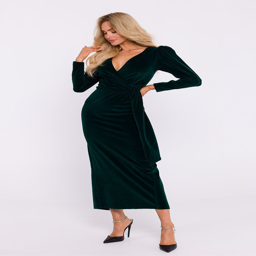

📌 Occasion: a formal dress
👕 Sleeve Length: a 3/4 sleeve dress
📏 Neckline: a V-neck dress
🎨 Pattern: a plain dress


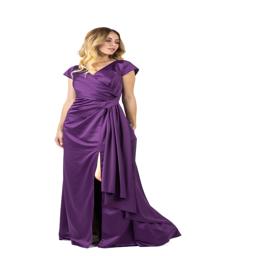

📌 Occasion: a formal dress
👕 Sleeve Length: a sleeveless dress
📏 Neckline: a high neck dress
🎨 Pattern: a plain dress


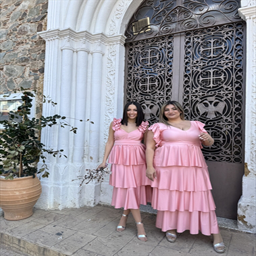

📌 Occasion: a party dress
👕 Sleeve Length: a 3/4 sleeve dress
📏 Neckline: a high neck dress
🎨 Pattern: a plain dress


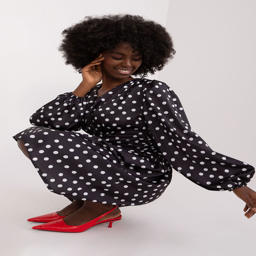

📌 Occasion: a party dress
👕 Sleeve Length: a 3/4 sleeve dress
📏 Neckline: a round neck dress
🎨 Pattern: a polka dot dress


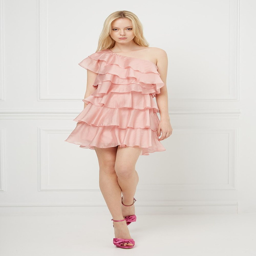

📌 Occasion: a party dress
👕 Sleeve Length: a sleeveless dress
📏 Neckline: a high neck dress
🎨 Pattern: a plain dress


In [22]:
from PIL import Image
from IPython.display import display
import requests
from io import BytesIO

# Show N samples with predictions and image
N = 5
for i, row in df_attr.dropna(subset=["mainImage.original_url"]).sample(N).iterrows():
    try:
        response = requests.get(row["mainImage.original_url"], timeout=5)
        img = Image.open(BytesIO(response.content)).resize((256, 256))
        display(img)

        print(f"📌 Occasion: {row['Occasion']}")
        print(f"👕 Sleeve Length: {row['Sleeve Length']}")
        print(f"📏 Neckline: {row['Neckline']}")
        print(f"🎨 Pattern: {row['Pattern']}")
        print("="*50)

    except Exception as e:
        print("❌ Could not load image:", e)


## A/B Prompt Testing for CLIP-Based Visual Attribute Prediction on Dress Images

To improve the accuracy of visual attribute predictions (like occasion, sleeve length, neckline, and pattern) for fashion images using the CLIP model by testing whether more descriptive, natural-language prompts produce better results than short, generic prompts.

CLIP (Contrastive Language–Image Pre-training) is a model that understands both images and text and can match them in a shared embedding space. In this project, CLIP is used to extract structured fashion attributes from unlabelled dress images by comparing each image to a list of possible textual prompts.

However, CLIP's predictions are highly dependent on the wording of these prompts. This makes prompt engineering crucial for accurate attribute extraction.

#### Testing Procedure
Sample a few dress image URLs from the dataset.

For each image:

1. Run attribute prediction with both Set A and Set B.
2. Compare the predictions side by side.
3. Display the image and evaluate the correctness visually.
4. Identify which prompt version (A or B) gives more accurate, human-aligned results.

We'll define:
- Set A = Your current basic prompts
- Set B = New descriptive, natural-language prompts

In [36]:
# Basic prompts (Set A)
attribute_prompts_A = {
    "Occasion": ["a party dress", "a casual dress", "a formal dress", "a wedding dress", "a beach dress"],
    "Sleeve Length": ["a short sleeve dress", "a long sleeve dress", "a sleeveless dress", "a 3/4 sleeve dress"],
    "Neckline": ["a V-neck dress", "a round neck dress", "a high neck dress", "a square neck dress"],
    "Pattern": ["a plain dress", "a floral dress", "a striped dress", "a polka dot dress", "an abstract dress"]
}

# Improved prompts (Set B)
attribute_prompts_B = {
    "Occasion": [
        "This is a glamorous party dress for special events.",
        "This is a relaxed, casual dress for everyday wear.",
        "This is a formal dress suitable for professional settings.",
        "This is a wedding guest dress for ceremonies.",
        "This is a lightweight dress perfect for the beach."
    ],
    "Sleeve Length": [
        "This dress has short flutter sleeves.",
        "This dress has long, full-length sleeves.",
        "This dress is sleeveless, showing the shoulders.",
        "This dress has sleeves that reach three-quarters down the arm."
    ],
    "Neckline": [
        "This dress features a deep V-neckline.",
        "This dress has a classic round neckline.",
        "This dress has a high neckline that covers the chest.",
        "This dress features a wide square neckline."
    ],
    "Pattern": [
        "This dress is solid-colored with no visible patterns.",
        "This dress has a bold floral print.",
        "This dress has horizontal or vertical stripes.",
        "This dress features evenly spaced polka dots.",
        "This dress has an artistic abstract pattern."
    ]
}

In [37]:
def predict_attributes(image_url, prompt_set):
    try:
        img_data = requests.get(image_url, timeout=5).content
        image = Image.open(BytesIO(img_data)).convert("RGB")
    except:
        return {"error": "Image could not be loaded"}

    result = {}
    for attr, prompts in prompt_set.items():
        inputs = clip_processor(text=prompts, images=image, return_tensors="pt", padding=True)
        with torch.no_grad():
            outputs = clip_model(**inputs)
        probs = outputs.logits_per_image.softmax(dim=1)[0]
        result[attr] = prompts[probs.argmax().item()]
    return result


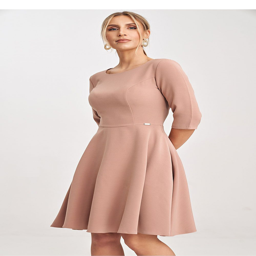

🆚 A/B Prompt Comparison
Occasion:
  A → a formal dress
  B → This is a wedding guest dress for ceremonies.
Sleeve Length:
  A → a 3/4 sleeve dress
  B → This dress is sleeveless, showing the shoulders.
Neckline:
  A → a round neck dress
  B → This dress has a classic round neckline.
Pattern:
  A → a plain dress
  B → This dress is solid-colored with no visible patterns.
————————————————————————————————————————————————————————————


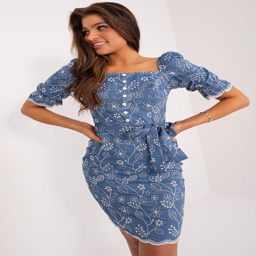

🆚 A/B Prompt Comparison
Occasion:
  A → a party dress
  B → This is a lightweight dress perfect for the beach.
Sleeve Length:
  A → a 3/4 sleeve dress
  B → This dress has short flutter sleeves.
Neckline:
  A → a round neck dress
  B → This dress features a deep V-neckline.
Pattern:
  A → a floral dress
  B → This dress has a bold floral print.
————————————————————————————————————————————————————————————


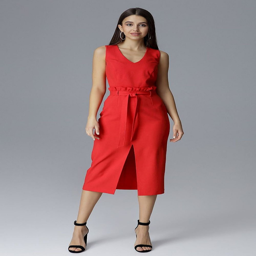

🆚 A/B Prompt Comparison
Occasion:
  A → a formal dress
  B → This is a lightweight dress perfect for the beach.
Sleeve Length:
  A → a short sleeve dress
  B → This dress is sleeveless, showing the shoulders.
Neckline:
  A → a square neck dress
  B → This dress features a wide square neckline.
Pattern:
  A → a plain dress
  B → This dress is solid-colored with no visible patterns.
————————————————————————————————————————————————————————————


In [38]:
from IPython.display import display
import matplotlib.pyplot as plt

sample_urls = df_attr["mainImage.original_url"].dropna().sample(3, random_state=42)

for url in sample_urls:
    # Display image
    try:
        image = Image.open(BytesIO(requests.get(url).content)).resize((256, 256))
        display(image)
    except:
        print("❌ Failed to load:", url)
        continue

    # Run both versions
    pred_A = predict_attributes(url, attribute_prompts_A)
    pred_B = predict_attributes(url, attribute_prompts_B)

    # Print predictions side by side
    print("🆚 A/B Prompt Comparison")
    for attr in attribute_prompts_A:
        print(f"{attr}:")
        print(f"  A → {pred_A[attr]}")
        print(f"  B → {pred_B[attr]}")
    print("—" * 60)


What This Tells Us:
- Descriptive prompts (Set B) help in many cases, especially with:
Fine-grained detail: sleeves, neckline, subtle patterns
- Avoiding ambiguous short terms like "short sleeve" or "floral"

 But short prompts (Set A) sometimes match better, especially when:
- The image clearly matches one of the basic categories (like "a formal dress")
- The longer prompt overfits to a misleading visual context (like "beach")

The best path forward is not to pick only one prompt set, but instead to:
Combine strengths of both:
- Use both A and B prompts during prediction.
- Choose the one with higher softmax probability.
- Optionally: ensemble their results.

In [41]:
# Set A: Short prompts
attribute_prompts_A = {
    "Occasion": ["a party dress", "a casual dress", "a formal dress", "a wedding dress", "a beach dress"],
    "Sleeve Length": ["a short sleeve dress", "a long sleeve dress", "a sleeveless dress", "a 3/4 sleeve dress"],
    "Neckline": ["a V-neck dress", "a round neck dress", "a high neck dress", "a square neck dress"],
    "Pattern": ["a plain dress", "a floral dress", "a striped dress", "a polka dot dress", "an abstract dress"]
}

# Set B: Descriptive prompts
attribute_prompts_B = {
    "Occasion": [
        "This is a glamorous party dress for special events.",
        "This is a relaxed, casual dress for everyday wear.",
        "This is a formal dress suitable for professional settings.",
        "This is a wedding guest dress for ceremonies.",
        "This is a lightweight dress perfect for the beach."
    ],
    "Sleeve Length": [
        "This dress has short flutter sleeves.",
        "This dress has long, full-length sleeves.",
        "This dress is sleeveless, showing the shoulders.",
        "This dress has sleeves that reach three-quarters down the arm."
    ],
    "Neckline": [
        "This dress features a deep V-neckline.",
        "This dress has a classic round neckline.",
        "This dress has a high neckline that covers the chest.",
        "This dress features a wide square neckline."
    ],
    "Pattern": [
        "This dress is solid-colored with no visible patterns.",
        "This dress has a bold floral print.",
        "This dress has horizontal or vertical stripes.",
        "This dress features evenly spaced polka dots.",
        "This dress has an artistic abstract pattern."
    ]
}

In [42]:
def predict_combined_best(image_url, prompts_A, prompts_B):
    try:
        img_data = requests.get(image_url, timeout=5).content
        image = Image.open(BytesIO(img_data)).convert("RGB")
    except:
        return {"error": "Image could not be loaded"}

    result = {}
    for attr in prompts_A.keys():
        # Process A
        inputs_A = clip_processor(text=prompts_A[attr], images=image, return_tensors="pt", padding=True)
        with torch.no_grad():
            outputs_A = clip_model(**inputs_A)
        probs_A = outputs_A.logits_per_image.softmax(dim=1)[0]
        max_prob_A = probs_A.max().item()
        best_A = prompts_A[attr][probs_A.argmax().item()]

        # Process B
        inputs_B = clip_processor(text=prompts_B[attr], images=image, return_tensors="pt", padding=True)
        with torch.no_grad():
            outputs_B = clip_model(**inputs_B)
        probs_B = outputs_B.logits_per_image.softmax(dim=1)[0]
        max_prob_B = probs_B.max().item()
        best_B = prompts_B[attr][probs_B.argmax().item()]

        # Choose the most confident prediction
        result[attr] = best_A if max_prob_A >= max_prob_B else best_B

    return result


In [43]:
# Run on an Image
# Example usage on a single image URL
url = df_attr["mainImage.original_url"].dropna().iloc[105]
print(predict_combined_best(url, attribute_prompts_A, attribute_prompts_B))


{'Occasion': 'a formal dress', 'Sleeve Length': 'a 3/4 sleeve dress', 'Neckline': 'a round neck dress', 'Pattern': 'a plain dress'}


In [44]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import textwrap

def visualize_clip_predictions(image_url, predictions, title="CLIP Attribute Prediction"):
    try:
        response = requests.get(image_url, timeout=5)
        image = Image.open(BytesIO(response.content)).convert("RGB")
    except:
        print("❌ Could not load image.")
        return
    
    # Plot image
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title(title, fontsize=14, fontweight="bold", pad=15)

    # Prepare text block (below image)
    text_lines = []
    emoji_map = {
        "Occasion": "📌",
        "Sleeve Length": "👕",
        "Neckline": "📏",
        "Pattern": "🎨"
    }
    
    for attr, pred in predictions.items():
        line = f"{emoji_map.get(attr, '')} {attr}: {pred}"
        text_lines.append(line)

    # Draw text box
    wrapped = "\n".join(textwrap.wrap("\n".join(text_lines), width=60))
    plt.figtext(0.5, -0.1, wrapped, ha="center", fontsize=12, family="monospace")
    
    plt.tight_layout()
    plt.show()


/Users/elinazachariou/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/elinazachariou/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128085 (\N{T-SHIRT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/elinazachariou/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/elinazachariou/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


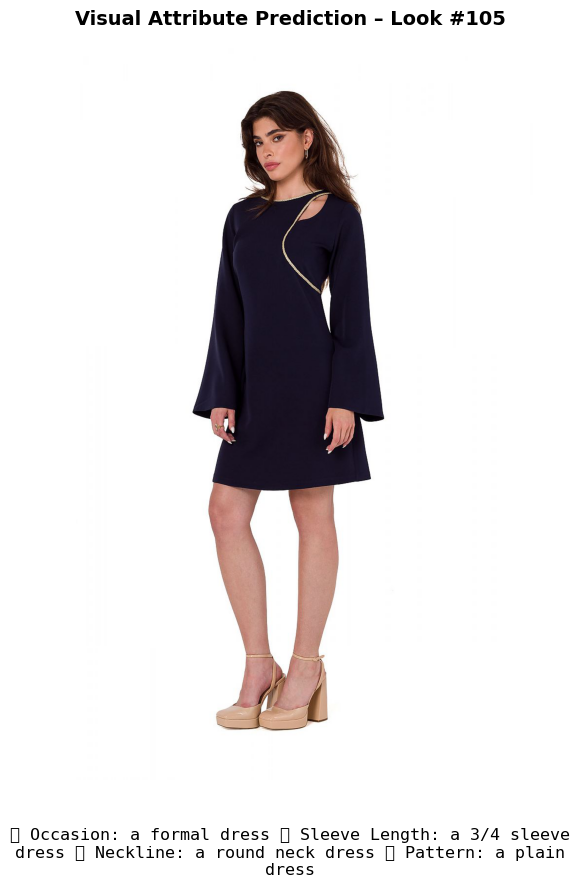

In [45]:
url = df_attr["mainImage.original_url"].dropna().iloc[105]
pred = predict_combined_best(url, attribute_prompts_A, attribute_prompts_B)
visualize_clip_predictions(url, pred, title="Visual Attribute Prediction – Look #105")

In [46]:
## not a 3/4 sleeve

In [47]:
#### If we want to apply the above to the entire dataframe

In [48]:
# # Apply across the whole dataframe
# from tqdm import tqdm
# tqdm.pandas()

# df_attr["combined_attributes"] = df_attr["mainImage.original_url"].progress_apply(
#     lambda url: predict_combined_best(url, attribute_prompts_A, attribute_prompts_B)
# )


In [49]:
# combined_df = pd.json_normalize(df_attr["combined_attributes"])
# df_attr_combined = pd.concat([df_attr.reset_index(drop=True), combined_df], axis=1)


## Combine CLIP with Fashion-Specific Object Detection

In [ ]:
pip install ultralytics


image 1/1 /var/folders/fp/nb_wxdjs0qn5lrs3lp6x5qjw0000gn/T/tmp4eszghxi.jpg: 640x448 1 person, 68.7ms
Speed: 3.1ms preprocess, 68.7ms inference, 11.1ms postprocess per image at shape (1, 3, 640, 448)


[W ParallelNative.cpp:230] Warning: Cannot set number of intraop threads after parallel work has started or after set_num_threads call when using native parallel backend (function set_num_threads)


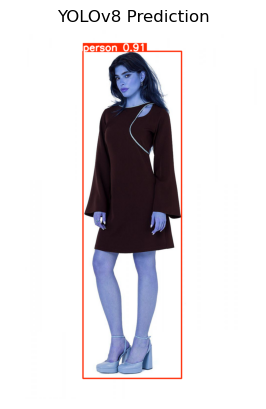

In [51]:
from ultralytics import YOLO
import requests
from PIL import Image
from io import BytesIO
import tempfile
import matplotlib.pyplot as plt

# Load YOLO model
model = YOLO("yolov8n.pt")  # You can use 'yolov8s.pt' or a custom model

# Get an image URL from your dataframe
url = df_attr["mainImage.original_url"].dropna().iloc[105]

# Download and open image
response = requests.get(url, timeout=5)
image = Image.open(BytesIO(response.content)).convert("RGB")

# Save to a temporary file
with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as tmp_file:
    image.save(tmp_file.name)
    temp_path = tmp_file.name

# Run YOLO on the image
results = model(temp_path)

# Get the rendered image (with bounding boxes drawn)
rendered_image = Image.fromarray(results[0].plot())

# Show using matplotlib (Jupyter-safe)
plt.imshow(rendered_image)
plt.axis('off')
plt.title("YOLOv8 Prediction")
plt.show()


  0%|                                                     | 0/3 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
100%|█████████████████████████████████████████████| 3/3 [00:02<00:00,  1.25it/s]


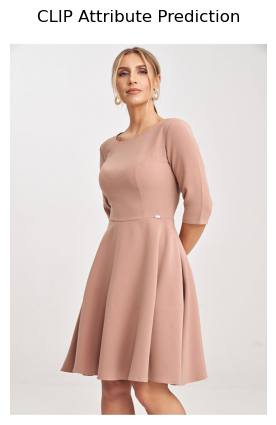

🧷 Occasion: a formal dress
🧷 Sleeve Length: a 3/4 sleeve dress
🧷 Neckline: a round neck dress
🧷 Pattern: a plain dress
--------------------------------------------------


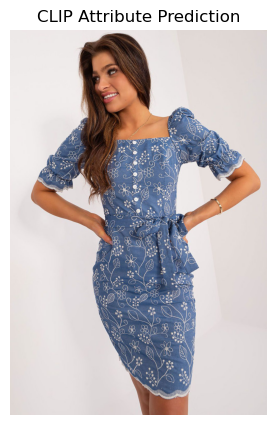

🧷 Occasion: a party dress
🧷 Sleeve Length: a 3/4 sleeve dress
🧷 Neckline: a round neck dress
🧷 Pattern: a floral dress
--------------------------------------------------


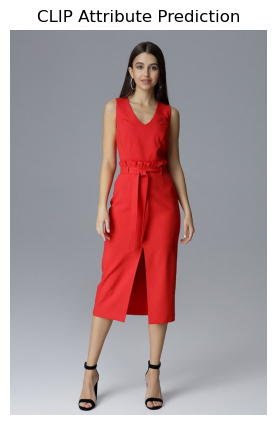

🧷 Occasion: a formal dress
🧷 Sleeve Length: a short sleeve dress
🧷 Neckline: a square neck dress
🧷 Pattern: a plain dress
--------------------------------------------------


23029    None
22584    None
12645    None
dtype: object

In [54]:
import pandas as pd
import ast
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
from transformers import CLIPProcessor, CLIPModel

tqdm.pandas()

# ------------------------
# ✅ Load your data
# ------------------------
df_attr = pd.read_csv("dresses_with_visual_attributes.csv", low_memory=False)

# ------------------------
# ✅ Initialize CLIP model
# ------------------------
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# ------------------------
# ✅ Define attribute prompts
# ------------------------
attribute_prompts = {
    "Occasion": ["a party dress", "a casual dress", "a formal dress", "a wedding dress", "a beach dress"],
    "Sleeve Length": ["a short sleeve dress", "a long sleeve dress", "a sleeveless dress", "a 3/4 sleeve dress"],
    "Neckline": ["a V-neck dress", "a round neck dress", "a high neck dress", "a square neck dress"],
    "Pattern": ["a plain dress", "a floral dress", "a striped dress", "a polka dot dress", "an abstract dress"]
}

# ------------------------
# ✅ Define CLIP prediction function
# ------------------------
def extract_attributes_from_url(image_url):
    try:
        headers = {"User-Agent": "Mozilla/5.0"}
        response = requests.get(image_url, headers=headers, timeout=5)
        response.raise_for_status()
        image = Image.open(BytesIO(response.content)).convert("RGB")
    except Exception as e:
        return {"error": f"Image could not be loaded: {e}"}

    result = {}
    for attr, prompts in attribute_prompts.items():
        try:
            inputs = clip_processor(text=prompts, images=image, return_tensors="pt", padding=True)
            with torch.no_grad():
                outputs = clip_model(**inputs)
            probs = outputs.logits_per_image.softmax(dim=1)[0]
            result[attr] = prompts[probs.argmax().item()]
        except:
            result[attr] = "unknown"
    return result

# ------------------------
# ✅ Apply prediction to a sample (safe)
# ------------------------
sample_df = df_attr.dropna(subset=["mainImage.original_url"]).sample(3, random_state=42).copy()
sample_df["clip_attributes"] = sample_df["mainImage.original_url"].progress_apply(extract_attributes_from_url)

# 🔁 To do it for all rows, uncomment this:
# df_attr["clip_attributes"] = df_attr["mainImage.original_url"].progress_apply(extract_attributes_from_url)

# ------------------------
# ✅ Visualization function
# ------------------------
def show_prediction(row):
    url = row["mainImage.original_url"]
    predictions = row["clip_attributes"]

    if isinstance(predictions, str):
        try:
            predictions = ast.literal_eval(predictions)
        except:
            predictions = None
    if not isinstance(predictions, dict):
        print("⚠️ No predictions")
        return

    try:
        headers = {"User-Agent": "Mozilla/5.0"}
        response = requests.get(url, headers=headers, timeout=5)
        image = Image.open(BytesIO(response.content)).convert("RGB")

        plt.figure(figsize=(5, 5))
        plt.imshow(image)
        plt.axis("off")
        plt.title("CLIP Attribute Prediction")
        plt.show()

        for key, val in predictions.items():
            print(f"🧷 {key}: {val}")
        print("-" * 50)

    except Exception as e:
        print(f"❌ Failed to load image: {e}")

# ------------------------
# ✅ Show predictions for the sample
# ------------------------
sample_df.apply(show_prediction, axis=1)


In [76]:
df_attr["clip_attributes"].dropna().head(5).apply(lambda x: print(x, type(x)))


{'Occasion': 'a formal dress', 'Sleeve Length': 'a 3/4 sleeve dress', 'Neckline': 'a round neck dress', 'Pattern': 'a plain dress'} <class 'dict'>
{'Occasion': 'a beach dress', 'Sleeve Length': 'a sleeveless dress', 'Neckline': 'a V-neck dress', 'Pattern': 'a plain dress'} <class 'dict'>
{'Occasion': 'a formal dress', 'Sleeve Length': 'a 3/4 sleeve dress', 'Neckline': 'a round neck dress', 'Pattern': 'a plain dress'} <class 'dict'>
{'Occasion': 'a formal dress', 'Sleeve Length': 'a 3/4 sleeve dress', 'Neckline': 'a round neck dress', 'Pattern': 'a plain dress'} <class 'dict'>
{'Occasion': 'a formal dress', 'Sleeve Length': 'a 3/4 sleeve dress', 'Neckline': 'a round neck dress', 'Pattern': 'a plain dress'} <class 'dict'>


499     None
821     None
1412    None
2229    None
2507    None
Name: clip_attributes, dtype: object

In [ ]:
## some  none again?

In [ ]:
### BUT THE ABOVE APPROACH GAVE THE MOST ACCURATE RESULTS TO THOSE NOT NONE!!!

## Approach: YOLO-assisted CLIP Attribute Prediction for Dress Images

This method performs visual attribute extraction from dress images by first detecting the person (dress wearer) using a YOLOv5 object detector. It then feeds the cropped person region into a CLIP model alongside attribute prompts to classify attributes like Occasion, Sleeve Length, Neckline, and Pattern. This improves prediction quality by focusing on the relevant region and removing noisy background.

In [90]:
# --- INSTALL REQUIRED PACKAGES ---
!pip install -q transformers torch torchvision pillow requests tqdm ultralytics

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


DEPRECATION: Loading egg at /Users/elinazachariou/anaconda3/lib/python3.11/site-packages/dlib-19.24.99-py3.11-macosx-11.1-arm64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.



100%|██████████████████████████████████████| 17.7M/17.7M [00:00<00:00, 20.4MB/s]
  0%|                                                    | 0/10 [00:00<?, ?it/s][W ParallelNative.cpp:230] Warning: Cannot set number of intraop threads after parallel work has started or after set_num_threads call when using native parallel backend (function set_num_threads)



0: 640x448 1 person, 292.1ms
Speed: 6.5ms preprocess, 292.1ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 448)


 20%|████████▊                                   | 2/10 [00:02<00:09,  1.20s/it]


0: 640x448 1 person, 100.0ms
Speed: 2.1ms preprocess, 100.0ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 448)


...


0: 640x640 1 person, 140.2ms
Speed: 2.4ms preprocess, 140.2ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


100%|███████████████████████████████████████████| 10/10 [00:06<00:00,  1.71it/s]


0: 640x448 1 person, 84.1ms
Speed: 3.3ms preprocess, 84.1ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 448)


100%|███████████████████████████████████████████| 10/10 [00:07<00:00,  1.37it/s]



🔗 https://cdn.shopify.com/s/files/1/0795/9343/9557/files/custom1000x1500_1034340.jpg?v=1720014339


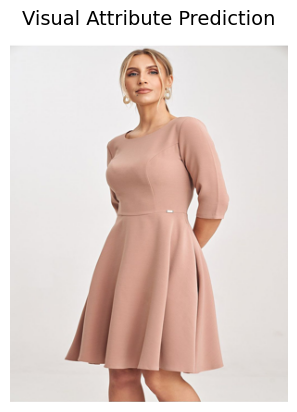

🔹 Occasion: a formal dress
🔹 Sleeve Length: a 3/4 sleeve dress
🔹 Neckline: a round neck dress
🔹 Pattern: a plain dress


In [94]:
# --- IMPORTS ---
import pandas as pd
import torch
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import requests
from io import BytesIO
from tqdm import tqdm
from ultralytics import YOLO
import matplotlib.pyplot as plt

# --- LOAD DATASET ---
df = pd.read_csv("dresses_with_visual_attributes.csv", low_memory=False)  # Update filename here
df = df.dropna(subset=["mainImage.original_url"]).reset_index(drop=True)

# --- LOAD MODELS ---
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
yolo_model = YOLO("yolov5s.pt")  # person detector

# --- ATTRIBUTE PROMPTS ---
attribute_prompts = {
    "Occasion": ["a party dress", "a casual dress", "a formal dress", "a wedding dress", "a beach dress"],
    "Sleeve Length": ["a short sleeve dress", "a long sleeve dress", "a sleeveless dress", "a 3/4 sleeve dress"],
    "Neckline": ["a V-neck dress", "a round neck dress", "a high neck dress", "a square neck dress"],
    "Pattern": ["a plain dress", "a floral dress", "a striped dress", "a polka dot dress", "an abstract dress"]
}

# --- ATTRIBUTE PREDICTION FUNCTION ---
def extract_attributes_with_yolo_clip(image_url):
    try:
        img_data = requests.get(image_url, timeout=10).content
        image = Image.open(BytesIO(img_data)).convert("RGB")

        # Detect person with YOLO
        results = yolo_model(image)
        boxes = results[0].boxes

        person_boxes = [box.xyxy[0].tolist() for box in boxes if int(box.cls[0]) == 0]  # class 0 = person
        if not person_boxes:
            return {"error": "No person detected"}

        # Crop first detected person
        x1, y1, x2, y2 = map(int, person_boxes[0])
        cropped_image = image.crop((x1, y1, x2, y2))

        # Predict attributes with CLIP
        result = {}
        for attr, prompts in attribute_prompts.items():
            inputs = clip_processor(text=prompts, images=cropped_image, return_tensors="pt", padding=True)
            with torch.no_grad():
                outputs = clip_model(**inputs)
            probs = outputs.logits_per_image.softmax(dim=1)[0]
            result[attr] = prompts[probs.argmax().item()]
        return result

    except Exception as e:
        return {"error": str(e)}

# --- APPLY TO SAMPLE ROWS (FAST TEST FIRST) ---
tqdm.pandas()
sample_df = df.sample(10, random_state=42).copy()
sample_df["clip_attributes"] = sample_df["mainImage.original_url"].progress_apply(extract_attributes_with_yolo_clip)

# --- SAVE SAMPLE RESULTS ---
sample_df.to_csv("sample_yolo_clip_predictions.csv", index=False)

# --- VISUALIZATION FUNCTION ---
def visualize_result(idx):
    row = sample_df.iloc[idx]
    url = row["mainImage.original_url"]
    pred = row["clip_attributes"]

    print(f"\n🔗 {url}")
    try:
        response = requests.get(url, timeout=10)
        image = Image.open(BytesIO(response.content)).resize((300, 400))
        plt.imshow(image)
        plt.axis('off')
        plt.title("Visual Attribute Prediction", fontsize=14)
        plt.show()
    except:
        print("⚠️ Could not load image.")

    if isinstance(pred, dict) and "error" not in pred:
        for k, v in pred.items():
            print(f"🔹 {k}: {v}")
    elif isinstance(pred, dict):
        print(f"❌ Prediction error: {pred['error']}")
    else:
        print(f"❌ Invalid prediction: {pred}")

# --- VISUALIZE FIRST PREDICTION ---
visualize_result(0)

# --- COMMENT TO RUN ON FULL DATASET ---
# df["clip_attributes"] = df["mainImage.original_url"].progress_apply(extract_attributes_with_yolo_clip)
# df.to_csv("dresses_with_visual_attributes_yolo_clip.csv", index=False)


🔗 https://eshop.hypercy.com/wp-content/uploads/2023/10/MONAMOURdressivoryf.jpg


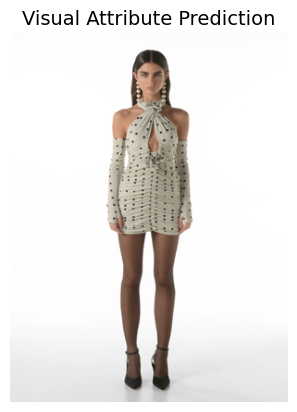

🔹 Occasion: a party dress
🔹 Sleeve Length: a short sleeve dress
🔹 Neckline: a round neck dress
🔹 Pattern: a polka dot dress


In [96]:
visualize_result(5)


🔗 https://cdn.shopify.com/s/files/1/0758/9973/2314/files/9CCCB7A4-1836-4E2A-9E3E-F94CFE3563E4.jpg?v=1746272670


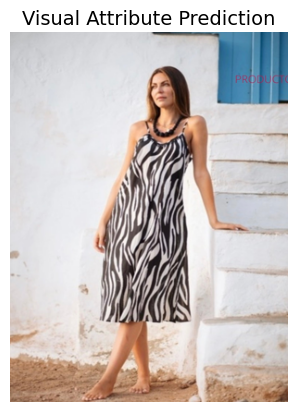

🔹 Occasion: a beach dress
🔹 Sleeve Length: a sleeveless dress
🔹 Neckline: a square neck dress
🔹 Pattern: a striped dress


In [102]:
visualize_result(4)

In [ ]:
### THIS APPROACH SEEMS TO BE THE BEST OF THEM ALL

In [ ]:
# --- UNCOMMENT THIS WHEN READY TO RUN ON FULL DATASET ---

# tqdm.pandas()
# df["clip_attributes"] = df["mainImage.original_url"].progress_apply(extract_attributes_with_yolo_clip)
# df.to_csv("dresses_with_visual_attributes_yolo_clip.csv", index=False)
# print("✅ Full dataset processed and saved.")


In [ ]:
## It might take a while depending on your dataset size and internet speed 
## (downloading images + running inference).

In this improved pipeline, we aim to extract **accurate visual attributes** (e.g., *Occasion*, *Sleeve Length*, *Neckline*, *Pattern*) from product images using a combination of **YOLO object detection** and **CLIP zero-shot classification**.

Instead of directly feeding the full product images to CLIP (as done in the initial pipeline), we first use **YOLOv5** to detect the `person` within each image—ensuring we crop the image tightly around the region that contains the actual dress. This filtered region is then passed to CLIP along with predefined prompts per attribute, significantly improving accuracy by reducing distractions like background objects or empty white space.

We reuse the previously generated CSV (`dresses_with_visual_attributes.csv`) from the initial CLIP-only approach because it already contains:

- Cleaned and filtered image URLs (`mainImage.original_url`)
- Useful product metadata (e.g., brand, color, size)
- Avoids reloading or preprocessing raw data again

Although this CSV includes older CLIP predictions, they are **ignored** in this approach. Instead, CLIP is reapplied to **YOLO-cropped** dress regions for better results.

##### Potential Improvement: Fallback for Failed Images

Some image URLs may be broken, unavailable, or error-prone. A possible robustness enhancement would be:

1. **Attempt fallback URLs**, such as:
   - `secondary_image_1.original_url`
   - `secondary_image_2.original_url`
   - ...
2. **Only drop the row** if *all* image attempts fail.

This fallback logic can maximize image coverage and reduce unnecessary data loss from single-point failures.
